# Cournot Competition Game

This notebook demonstrates the Cournot competition game with two firms.

## Model
- Two firms choose quantities $q_1$ and $q_2$
- Price: $P = a - b \cdot Q$ where $Q = q_1 + q_2$
- Cost: $C_i = c \cdot q_i$
- Profit: $\pi_i = P \cdot q_i - C_i = (a - b \cdot Q) \cdot q_i - c \cdot q_i$

## Nash Equilibrium
For symmetric firms with linear demand and constant marginal cost:
- Equilibrium quantity: $q^* = \frac{a - c}{3b}$
- Equilibrium price: $P^* = a - 2b \cdot q^*$
- Equilibrium profit: $\pi^* = b \cdot (q^*)^2$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from games.cournot import Cournot
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent

## Initialize the Game

Default parameters: $a=25$, $b=2$, $c=1$

In [3]:
# Create game with default parameters
g = Cournot(a=25.0, b=2.0, c=1.0, max_quantity=10, num_actions=21)
g.reset()

## Nash Equilibrium

Calculate the theoretical Nash equilibrium:

In [4]:
q_star, P_star, profit_star = g.get_nash_equilibrium()
print(f"Nash Equilibrium:")
print(f"  Quantity per firm: {q_star:.4f}")
print(f"  Total quantity: {2*q_star:.4f}")
print(f"  Price: {P_star:.4f}")
print(f"  Profit per firm: {profit_star:.4f}")

Nash Equilibrium:
  Quantity per firm: 4.0000
  Total quantity: 8.0000
  Price: 9.0000
  Profit per firm: 32.0000


## Visualize Best Response Functions

Plot the best response functions for both firms:

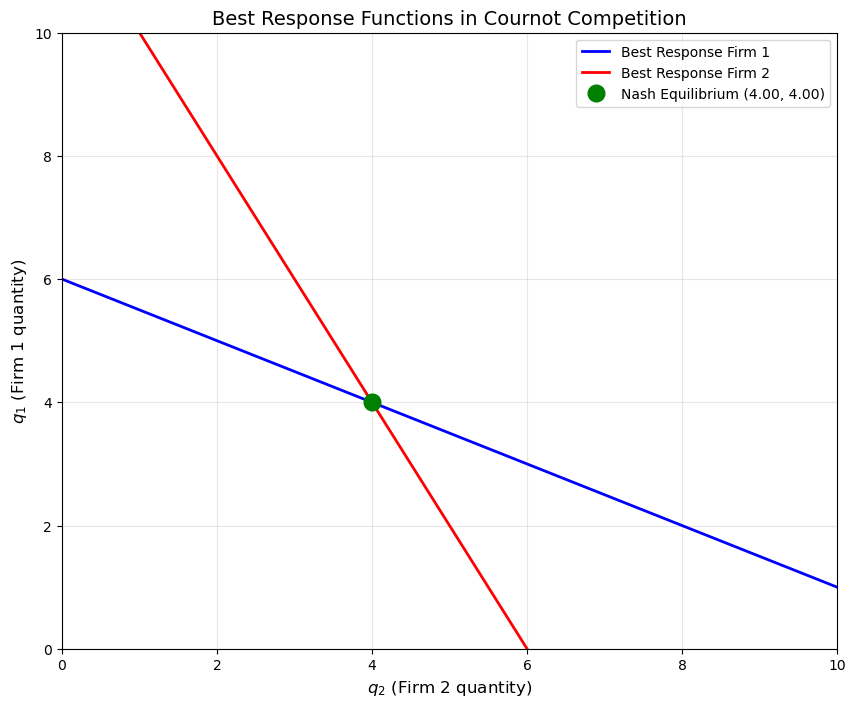

In [6]:
# Create a grid of quantities
q_range = np.linspace(0, g.max_quantity, 100)

# Best response for firm 1 given firm 2's quantity
# Maximize π_1 = (a - b*(q_1 + q_2))*q_1 - c*q_1
# FOC: a - 2*b*q_1 - b*q_2 - c = 0
# q_1^BR = (a - c - b*q_2) / (2*b)
def best_response(q_j, a, b, c):
    br = (a - c - b*q_j) / (2*b)
    return np.maximum(0, br)  # quantity cannot be negative

br_1 = best_response(q_range, g.a, g.b, g.c)
br_2 = best_response(q_range, g.a, g.b, g.c)  # symmetric

plt.figure(figsize=(10, 8))
plt.plot(q_range, br_1, 'b-', linewidth=2, label='Best Response Firm 1')
plt.plot(br_2, q_range, 'r-', linewidth=2, label='Best Response Firm 2')
plt.plot(q_star, q_star, 'go', markersize=12, label=f'Nash Equilibrium ({q_star:.2f}, {q_star:.2f})')
plt.xlabel('$q_2$ (Firm 2 quantity)', fontsize=12)
plt.ylabel('$q_1$ (Firm 1 quantity)', fontsize=12)
plt.title('Best Response Functions in Cournot Competition', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, g.max_quantity])
plt.ylim([0, g.max_quantity])
plt.show()

## Learning with Regret Matching

In [17]:
g.reset()
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent, seed=42)), g.agents))

In [18]:
# Track convergence
iterations = 500
sample_rate = 10  # Collect data every N iterations
history = {'q1': [], 'q2': [], 'profit1': [], 'profit2': []}

for i in range(iterations):
    actions = dict(map(lambda agent: (agent, rm[agent].action()), g.agents))
    obs, rewards, terms, truncs, infos = g.step(actions)
    
    if i % sample_rate == 0:
        q1 = g._quantities[actions[g.agents[0]]]
        q2 = g._quantities[actions[g.agents[1]]]
        history['q1'].append(q1)
        history['q2'].append(q2)
        history['profit1'].append(rewards[g.agents[0]])
        history['profit2'].append(rewards[g.agents[1]])

print("Learned strategies (Regret Matching):")
for agent in g.agents:
    policy = rm[agent].policy()
    # Find the most probable quantity
    most_probable_action = np.argmax(policy)
    most_probable_quantity = g._quantities[most_probable_action]
    print(f"{agent}: Most probable quantity = {most_probable_quantity:.4f} (Nash: {q_star:.4f})")

Learned strategies (Regret Matching):
agent_0: Most probable quantity = 4.0000 (Nash: 4.0000)
agent_1: Most probable quantity = 4.0000 (Nash: 4.0000)


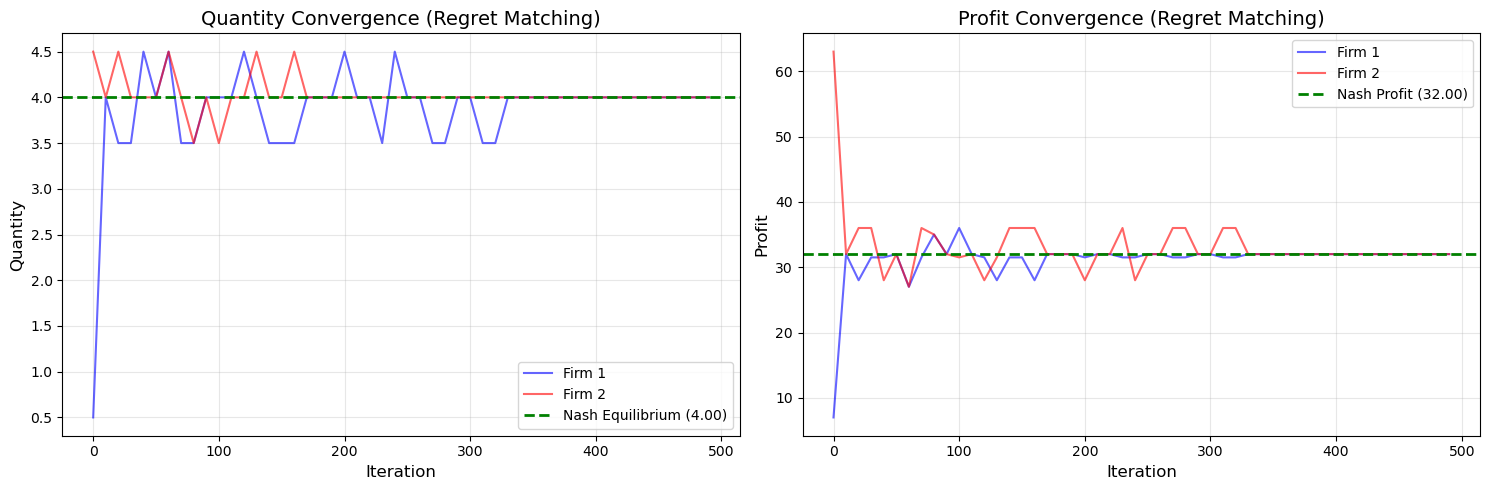

In [19]:
# Plot convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Quantities over time
iterations_plot = range(0, iterations, sample_rate)
ax1.plot(iterations_plot, history['q1'], 'b-', alpha=0.6, label='Firm 1')
ax1.plot(iterations_plot, history['q2'], 'r-', alpha=0.6, label='Firm 2')
ax1.axhline(y=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash Equilibrium ({q_star:.2f})')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Quantity', fontsize=12)
ax1.set_title('Quantity Convergence (Regret Matching)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Profits over time
ax2.plot(iterations_plot, history['profit1'], 'b-', alpha=0.6, label='Firm 1')
ax2.plot(iterations_plot, history['profit2'], 'r-', alpha=0.6, label='Firm 2')
ax2.axhline(y=profit_star, color='g', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star:.2f})')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Profit', fontsize=12)
ax2.set_title('Profit Convergence (Regret Matching)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Learning with Fictitious Play

In [22]:
g.reset()
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent, seed=42)), g.agents))

In [23]:
# Track convergence
iterations_fp = 500
sample_rate_fp = 10  # Collect data every N iterations
history_fp = {'q1': [], 'q2': [], 'profit1': [], 'profit2': []}

for i in range(iterations_fp):
    actions = dict(map(lambda agent: (agent, fp[agent].action()), g.agents))
    obs, rewards, terms, truncs, infos = g.step(actions)
    
    if i % sample_rate_fp == 0:
        q1 = g._quantities[actions[g.agents[0]]]
        q2 = g._quantities[actions[g.agents[1]]]
        history_fp['q1'].append(q1)
        history_fp['q2'].append(q2)
        history_fp['profit1'].append(rewards[g.agents[0]])
        history_fp['profit2'].append(rewards[g.agents[1]])

print("Learned strategies (Fictitious Play):")
for agent in g.agents:
    policy = fp[agent].policy()
    # Find the most probable quantity
    most_probable_action = np.argmax(policy)
    most_probable_quantity = g._quantities[most_probable_action]
    print(f"{agent}: Most probable quantity = {most_probable_quantity:.4f} (Nash: {q_star:.4f})")

Learned strategies (Fictitious Play):
agent_0: Most probable quantity = 4.0000 (Nash: 4.0000)
agent_1: Most probable quantity = 4.0000 (Nash: 4.0000)


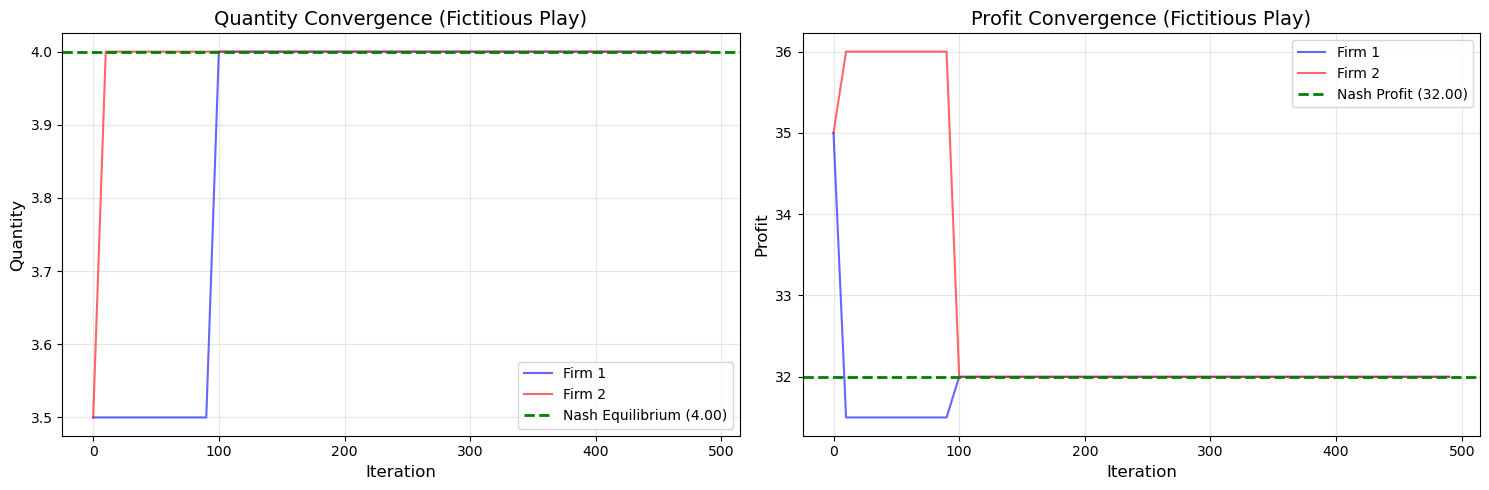

In [24]:
# Plot convergence for Fictitious Play
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Quantities over time
iterations_plot_fp = range(0, iterations_fp, sample_rate_fp)
ax1.plot(iterations_plot_fp, history_fp['q1'], 'b-', alpha=0.6, label='Firm 1')
ax1.plot(iterations_plot_fp, history_fp['q2'], 'r-', alpha=0.6, label='Firm 2')
ax1.axhline(y=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash Equilibrium ({q_star:.2f})')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Quantity', fontsize=12)
ax1.set_title('Quantity Convergence (Fictitious Play)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Profits over time
ax2.plot(iterations_plot_fp, history_fp['profit1'], 'b-', alpha=0.6, label='Firm 1')
ax2.plot(iterations_plot_fp, history_fp['profit2'], 'r-', alpha=0.6, label='Firm 2')
ax2.axhline(y=profit_star, color='g', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star:.2f})')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Profit', fontsize=12)
ax2.set_title('Profit Convergence (Fictitious Play)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Strategy Distribution

Visualize the learned strategy distributions:

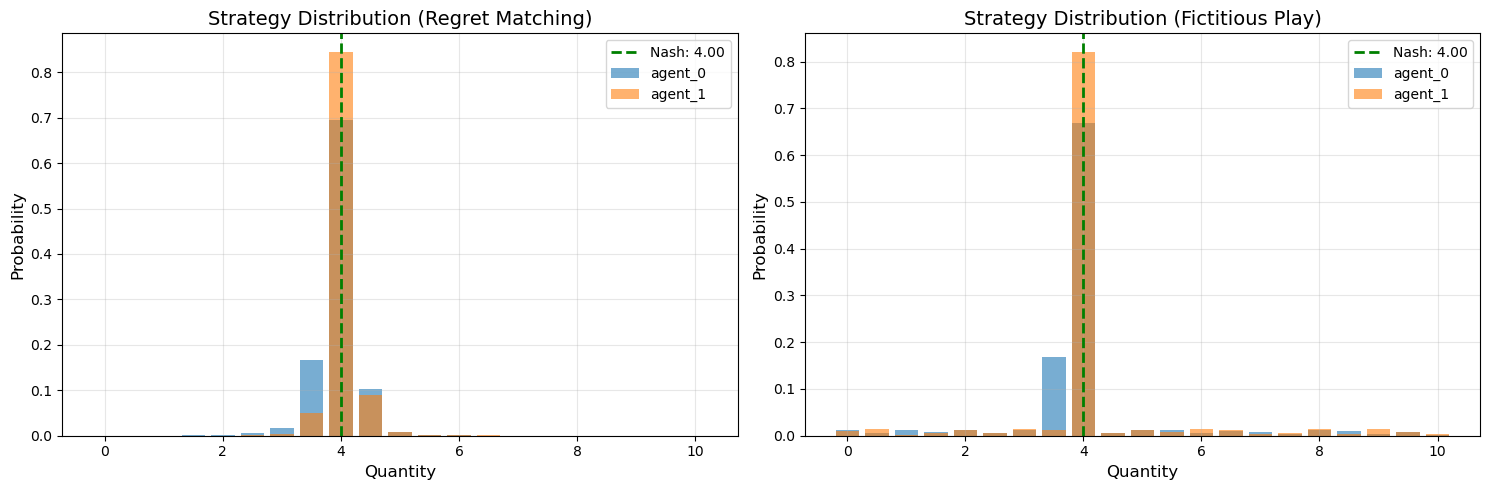

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Regret Matching
for agent in g.agents:
    policy = rm[agent].policy()
    ax1.bar(g._quantities, policy, alpha=0.6, label=agent, width=0.4)
ax1.axvline(x=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
ax1.set_xlabel('Quantity', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Strategy Distribution (Regret Matching)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fictitious Play
for agent in g.agents:
    policy = fp[agent].policy()
    ax2.bar(g._quantities, policy, alpha=0.6, label=agent, width=0.4)
ax2.axvline(x=q_star, color='g', linestyle='--', linewidth=2, label=f'Nash: {q_star:.2f}')
ax2.set_xlabel('Quantity', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Strategy Distribution (Fictitious Play)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Three-Player Cournot Competition

Now let's test the game with 3 firms to see how competition affects equilibrium outcomes.

## Nash Equilibrium for n Players

For n firms, the Nash equilibrium is:
- Equilibrium quantity per firm: $q^* = \frac{a - c}{(n+1)b}$
- Total market quantity: $Q^* = n \cdot q^*$
- Equilibrium price: $P^* = a - b \cdot Q^*$

In [26]:
# Create 3-player game with same parameters
g3 = Cournot(a=25.0, b=2.0, c=1.0, n_players=3, max_quantity=10, num_actions=21)
g3.reset()

print(f"Number of players: {g3.n_players}")
print(f"Agents: {g3.agents}")

Number of players: 3
Agents: ['agent_0', 'agent_1', 'agent_2']


## Nash Equilibrium (3 Players)

In [27]:
q_star_3, P_star_3, profit_star_3 = g3.get_nash_equilibrium()
print(f"Nash Equilibrium (3 players):")
print(f"  Quantity per firm: {q_star_3:.4f}")
print(f"  Total quantity: {3*q_star_3:.4f}")
print(f"  Price: {P_star_3:.4f}")
print(f"  Profit per firm: {profit_star_3:.4f}")
print(f"\nComparison with 2 players:")
print(f"  2 players: q*={q_star:.4f}, P*={P_star:.4f}, π*={profit_star:.4f}")
print(f"  3 players: q*={q_star_3:.4f}, P*={P_star_3:.4f}, π*={profit_star_3:.4f}")

Nash Equilibrium (3 players):
  Quantity per firm: 3.0000
  Total quantity: 9.0000
  Price: 7.0000
  Profit per firm: 18.0000

Comparison with 2 players:
  2 players: q*=4.0000, P*=9.0000, π*=32.0000
  3 players: q*=3.0000, P*=7.0000, π*=18.0000


## Test Nash Equilibrium Actions

In [28]:
# Test with Nash equilibrium quantities
g3.reset()
nash_action_3 = np.argmin(np.abs(g3._quantities - q_star_3))
actions_3 = {agent: nash_action_3 for agent in g3.agents}
obs, rewards, terms, truncs, infos = g3.step(actions_3)
g3.render()
print(f"\nExpected Nash profit: {profit_star_3:.4f}")

agent_0: quantity=3.00, profit=18.00
agent_1: quantity=3.00, profit=18.00
agent_2: quantity=3.00, profit=18.00

Expected Nash profit: 18.0000


## Learning with Regret Matching (3 Players)

In [34]:
g3.reset()
rm3 = dict(map(lambda agent: (agent, RegretMatching(game=g3, agent=agent, seed=42)), g3.agents))

In [35]:
# Track convergence for 3 players
iterations_3 = 1000
sample_rate_3 = 10  # Collect data every N iterations
history_3 = {'q': {agent: [] for agent in g3.agents}, 
             'profit': {agent: [] for agent in g3.agents}}

for i in range(iterations_3):
    actions = dict(map(lambda agent: (agent, rm3[agent].action()), g3.agents))
    obs, rewards, terms, truncs, infos = g3.step(actions)
    
    if i % sample_rate_3 == 0:
        for agent in g3.agents:
            q = g3._quantities[actions[agent]]
            history_3['q'][agent].append(q)
            history_3['profit'][agent].append(rewards[agent])

print("Learned strategies (Regret Matching - 3 players):")
for agent in g3.agents:
    policy = rm3[agent].policy()
    most_probable_action = np.argmax(policy)
    most_probable_quantity = g3._quantities[most_probable_action]
    print(f"{agent}: Most probable quantity = {most_probable_quantity:.4f} (Nash: {q_star_3:.4f})")

Learned strategies (Regret Matching - 3 players):
agent_0: Most probable quantity = 3.0000 (Nash: 3.0000)
agent_1: Most probable quantity = 3.0000 (Nash: 3.0000)
agent_2: Most probable quantity = 3.0000 (Nash: 3.0000)


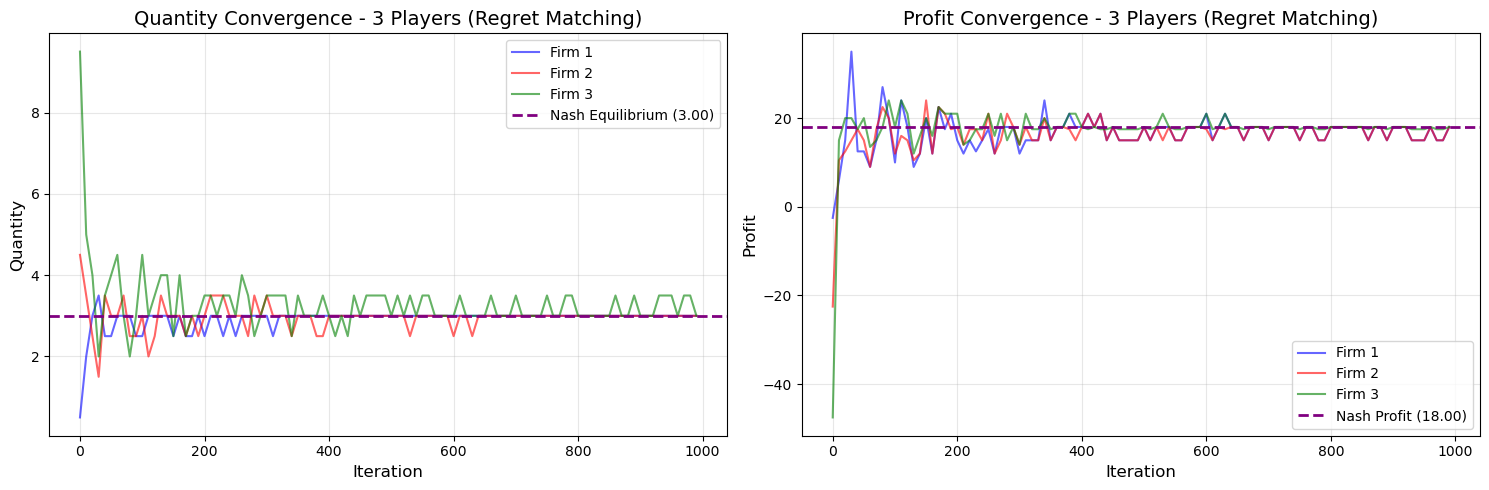

In [37]:
# Plot convergence for 3 players
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

iterations_plot_3 = range(0, iterations_3, sample_rate_3)
colors = ['b-', 'r-', 'g-']

# Quantities over time
for i, agent in enumerate(g3.agents):
    ax1.plot(iterations_plot_3, history_3['q'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
ax1.axhline(y=q_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash Equilibrium ({q_star_3:.2f})')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Quantity', fontsize=12)
ax1.set_title('Quantity Convergence - 3 Players (Regret Matching)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Profits over time
for i, agent in enumerate(g3.agents):
    ax2.plot(iterations_plot_3, history_3['profit'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
ax2.axhline(y=profit_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star_3:.2f})')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Profit', fontsize=12)
ax2.set_title('Profit Convergence - 3 Players (Regret Matching)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Learning with Fictitious Play (3 Players)

In [ ]:
g3.reset()
fp3 = dict(map(lambda agent: (agent, FictitiousPlay(game=g3, agent=agent, seed=42)), g3.agents))

In [ ]:
# Track convergence for 3 players with Fictitious Play
iterations_fp3 = 1000
sample_rate_fp3 = 10  # Collect data every N iterations
history_fp3 = {'q': {agent: [] for agent in g3.agents}, 
               'profit': {agent: [] for agent in g3.agents}}

for i in range(iterations_fp3):
    actions = dict(map(lambda agent: (agent, fp3[agent].action()), g3.agents))
    obs, rewards, terms, truncs, infos = g3.step(actions)
    
    if i % sample_rate_fp3 == 0:
        for agent in g3.agents:
            q = g3._quantities[actions[agent]]
            history_fp3['q'][agent].append(q)
            history_fp3['profit'][agent].append(rewards[agent])

print("Learned strategies (Fictitious Play - 3 players):")
for agent in g3.agents:
    policy = fp3[agent].policy()
    most_probable_action = np.argmax(policy)
    most_probable_quantity = g3._quantities[most_probable_action]
    print(f"{agent}: Most probable quantity = {most_probable_quantity:.4f} (Nash: {q_star_3:.4f})")

In [ ]:
# Plot convergence for 3 players with Fictitious Play
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

iterations_plot_fp3 = range(0, iterations_fp3, sample_rate_fp3)
colors = ['b-', 'r-', 'g-']

# Quantities over time
for i, agent in enumerate(g3.agents):
    ax1.plot(iterations_plot_fp3, history_fp3['q'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
ax1.axhline(y=q_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash Equilibrium ({q_star_3:.2f})')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Quantity', fontsize=12)
ax1.set_title('Quantity Convergence - 3 Players (Fictitious Play)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Profits over time
for i, agent in enumerate(g3.agents):
    ax2.plot(iterations_plot_fp3, history_fp3['profit'][agent], colors[i], alpha=0.6, label=f'Firm {i+1}')
ax2.axhline(y=profit_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash Profit ({profit_star_3:.2f})')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Profit', fontsize=12)
ax2.set_title('Profit Convergence - 3 Players (Fictitious Play)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Strategy Distribution (3 Players)

Visualize the learned strategy distributions for 3 players:

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Regret Matching
for i, agent in enumerate(g3.agents):
    policy = rm3[agent].policy()
    ax1.bar(g3._quantities + i*0.15, policy, alpha=0.6, label=f'Firm {i+1}', width=0.15)
ax1.axvline(x=q_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash: {q_star_3:.2f}')
ax1.set_xlabel('Quantity', fontsize=12)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Strategy Distribution - 3 Players (Regret Matching)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fictitious Play
for i, agent in enumerate(g3.agents):
    policy = fp3[agent].policy()
    ax2.bar(g3._quantities + i*0.15, policy, alpha=0.6, label=f'Firm {i+1}', width=0.15)
ax2.axvline(x=q_star_3, color='purple', linestyle='--', linewidth=2, label=f'Nash: {q_star_3:.2f}')
ax2.set_xlabel('Quantity', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Strategy Distribution - 3 Players (Fictitious Play)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison: 2 Players vs 3 Players

Compare market outcomes with different numbers of firms:

In [ ]:
# Create comparison table
comparison_data = {
    'Number of Firms': [2, 3],
    'q* (per firm)': [q_star, q_star_3],
    'Q* (total)': [2*q_star, 3*q_star_3],
    'P* (price)': [P_star, P_star_3],
    'π* (per firm)': [profit_star, profit_star_3],
    'Total Industry Profit': [2*profit_star, 3*profit_star_3]
}

print("Impact of Number of Firms on Market Outcomes:")
print("="*80)
print(f"{'Firms':<10} {'q* (each)':<12} {'Q* (total)':<12} {'P*':<10} {'π* (each)':<12} {'Total π*':<12}")
print("="*80)
for i in range(len(comparison_data['Number of Firms'])):
    n = comparison_data['Number of Firms'][i]
    q = comparison_data['q* (per firm)'][i]
    Q = comparison_data['Q* (total)'][i]
    P = comparison_data['P* (price)'][i]
    pi = comparison_data['π* (per firm)'][i]
    total_pi = comparison_data['Total Industry Profit'][i]
    print(f"{n:<10} {q:<12.4f} {Q:<12.4f} {P:<10.4f} {pi:<12.4f} {total_pi:<12.4f}")
print("="*80)
print("\nObservations:")
print("  • As the number of firms increases:")
print("    - Each firm produces less (q* decreases)")
print("    - Total market quantity increases (Q* increases)")
print("    - Price decreases (P* decreases)")
print("    - Profit per firm decreases (π* decreases)")
print("    - Total industry profit decreases")
print("  • Market becomes more competitive, approaching perfect competition")

In [ ]:
# Visualize the comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

n_firms = [2, 3]
q_per_firm = [q_star, q_star_3]
Q_total = [2*q_star, 3*q_star_3]
prices = [P_star, P_star_3]
profit_per_firm = [profit_star, profit_star_3]

# Quantity per firm
ax1.bar(n_firms, q_per_firm, color='skyblue', alpha=0.8, width=0.5)
ax1.set_xlabel('Number of Firms', fontsize=12)
ax1.set_ylabel('Quantity per Firm (q*)', fontsize=12)
ax1.set_title('Equilibrium Quantity per Firm', fontsize=13)
ax1.set_xticks(n_firms)
ax1.grid(True, alpha=0.3, axis='y')

# Total market quantity
ax2.bar(n_firms, Q_total, color='lightcoral', alpha=0.8, width=0.5)
ax2.set_xlabel('Number of Firms', fontsize=12)
ax2.set_ylabel('Total Market Quantity (Q*)', fontsize=12)
ax2.set_title('Total Market Output', fontsize=13)
ax2.set_xticks(n_firms)
ax2.grid(True, alpha=0.3, axis='y')

# Price
ax3.bar(n_firms, prices, color='lightgreen', alpha=0.8, width=0.5)
ax3.set_xlabel('Number of Firms', fontsize=12)
ax3.set_ylabel('Price (P*)', fontsize=12)
ax3.set_title('Equilibrium Price', fontsize=13)
ax3.set_xticks(n_firms)
ax3.grid(True, alpha=0.3, axis='y')

# Profit per firm
ax4.bar(n_firms, profit_per_firm, color='plum', alpha=0.8, width=0.5)
ax4.set_xlabel('Number of Firms', fontsize=12)
ax4.set_ylabel('Profit per Firm (π*)', fontsize=12)
ax4.set_title('Equilibrium Profit per Firm', fontsize=13)
ax4.set_xticks(n_firms)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()